In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib import colors
from skimage.feature import peak_local_max
from scipy.signal import find_peaks
import os
import pandas as pd
from skimage.filters import threshold_multiotsu
import random

In [2]:
# --- Draw rectangle safely ---
def draw_colored_rectangle(img, coords, color):
    if len(img.shape) == 2:  # grayscale → RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = img.copy()
    y1, y2, x1, x2 = coords
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 1)
    return img_rgb


def get_subregions_with_border(img, subregions, colors):
    sub_imgs = []
    for (coords, color) in zip(subregions, colors):
        y1, y2, x1, x2 = coords
        y1, y2 = sorted((y1, y2))
        x1, x2 = sorted((x1, x2))
        y2 = min(y2, img.shape[0])
        x2 = min(x2, img.shape[1])
        sub_img = img[y1:y2, x1:x2].copy()
        if sub_img.size == 0:
            continue
        height, width = sub_img.shape[:2]
        sub_img = draw_colored_rectangle(sub_img, (0, height-1, 0, width-1), color)
        sub_imgs.append(sub_img)
    return sub_imgs

In [3]:
stain_path = r'tonguedataset\Stain'
nonstain_path = r'tonguedataset\Non Stain'


def load_image_unicode(path):
    stream = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(stream, cv2.IMREAD_COLOR)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def resize_image(img, max_size=512):
    """Resize image so the longest side is max_size, maintaining aspect ratio."""
    h, w = img.shape[:2]
    scale = max_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    return cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

def impulse_noise(image, prob=0.02):
    """Add impulse (salt & pepper) noise to an image."""
    noisy_image = np.copy(image)
    rand = np.random.rand(*image.shape[:2], 1)
    black = rand < (prob / 2)
    white = rand > 1 - (prob / 2)
    noisy_image[black.squeeze()] = 0
    noisy_image[white.squeeze()] = 255
    return noisy_image


def random_noise(image, prob=0.8, darken_prob=0.4, darken_range=(0.5, 0.7)):
    dark = " "
    # --- 1. Skip noise entirely ---
    if random.random() > prob:
        return image, "none"

    # --- 2. Maybe darken the image ---
    if random.random() < darken_prob:
        factor = random.uniform(*darken_range)  # pick a random darkening level
        image = np.clip(image * factor, 0, 255).astype(np.uint8)
        dark = "darken_"

    # --- 3. Apply noise ---
    noise_type = random.choice(["impulse"])
    if noise_type == "impulse":
        return impulse_noise(image), "impulse"+dark

    return image, "none"

    
def load_images_range(folder, start=100, end=200, max_size=256, noise_prob=0.4):
    """Load images, resize, and optionally apply random noise."""
    files = sorted(
        [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    )[start:end]

    images, names, noise_types = [], [], []
    for name in files:
        img_path = os.path.join(folder, name)
        img = load_image_unicode(img_path)
        if img is not None:
            img = resize_image(img, max_size=max_size)
            img, noise_type = random_noise(img, prob=noise_prob)
            images.append(img)
            names.append(name)
            noise_types.append(noise_type)
    return images, names, noise_types


# --- Example usage ---
stain_images, stain_names, stain_noise = load_images_range(stain_path, 200, 300, max_size=512)
nonstain_images, nonstain_names, nonstain_noise = load_images_range(nonstain_path, 200, 300, max_size=512)

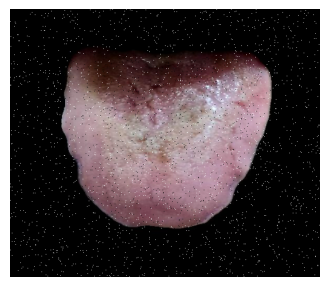

In [4]:
seg_img = stain_images[16]

# Display the segmented image
plt.figure(figsize=(4, 4))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


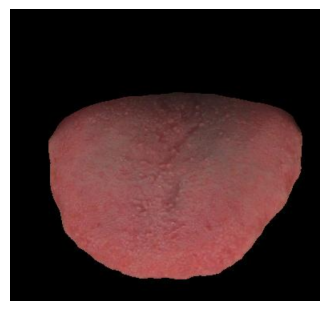

In [5]:
seg_img = stain_images[49]

# Display the segmented image
plt.figure(figsize=(4, 4))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

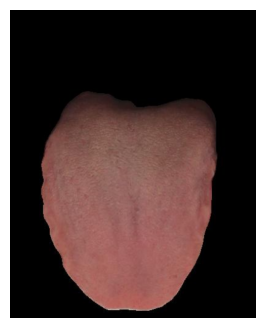

In [59]:
seg_img = stain_images[80]

# Display the segmented image
plt.figure(figsize=(4, 4))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

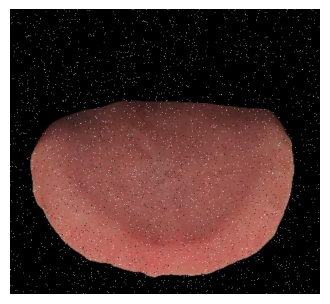

In [6]:
seg_img = stain_images[96]

# Display the segmented image
plt.figure(figsize=(4, 4))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [7]:
for idx, (name, noise) in enumerate(zip(stain_names, stain_noise)):
    print(f"Index: {idx} | Name: {name} | Noise: {noise}")

Index: 0 | Name: 27_彩虹糖.JPG | Noise: none
Index: 1 | Name: 280_彩虹糖.JPG | Noise: none
Index: 2 | Name: 281_橙子味糖果.JPG | Noise: impulsedarken_
Index: 3 | Name: 282_黑巧.JPG | Noise: none
Index: 4 | Name: 283_巧克力冰淇淋.JPG | Noise: none
Index: 5 | Name: 284_奥利奥饼干.JPG | Noise: impulsedarken_
Index: 6 | Name: 285_奶茶.JPG | Noise: impulse 
Index: 7 | Name: 286_茶颜悦色奶茶.JPG | Noise: impulse 
Index: 8 | Name: 287_茶颜悦色奶茶.JPG | Noise: impulse 
Index: 9 | Name: 288_茶颜悦色奶茶.JPG | Noise: none
Index: 10 | Name: 289_橙色彩虹糖.JPG | Noise: impulse 
Index: 11 | Name: 28_彩虹糖.JPG | Noise: impulsedarken_
Index: 12 | Name: 290_豆浆.JPG | Noise: none
Index: 13 | Name: 291_番茄酱.JPG | Noise: impulse 
Index: 14 | Name: 292_番茄酱.JPG | Noise: none
Index: 15 | Name: 293_芬达.JPG | Noise: none
Index: 16 | Name: 294_黄心猕猴桃.JPG | Noise: impulse 
Index: 17 | Name: 295_黑莓.JPG | Noise: none
Index: 18 | Name: 296_黑莓.JPG | Noise: none
Index: 19 | Name: 297_黑葡提.JPG | Noise: none
Index: 20 | Name: 298_黑巧.JPG | Noise: none
Index: 21 | Name: 299

In [8]:
for idx, (name, noise) in enumerate(zip(nonstain_names, nonstain_noise)):
    print(f"Index: {idx} | Name: {name} | Noise: {noise}")

Index: 0 | Name:  277.JPG | Noise: none
Index: 1 | Name:  278.JPG | Noise: impulsedarken_
Index: 2 | Name:  279.JPG | Noise: none
Index: 3 | Name:  28.JPG | Noise: impulsedarken_
Index: 4 | Name:  280.JPG | Noise: impulse 
Index: 5 | Name:  281.JPG | Noise: none
Index: 6 | Name:  282.JPG | Noise: impulse 
Index: 7 | Name:  283.JPG | Noise: impulse 
Index: 8 | Name:  284.JPG | Noise: none
Index: 9 | Name:  285.JPG | Noise: none
Index: 10 | Name:  286.JPG | Noise: none
Index: 11 | Name:  287.JPG | Noise: none
Index: 12 | Name:  288.JPG | Noise: none
Index: 13 | Name:  289.JPG | Noise: none
Index: 14 | Name:  29.JPG | Noise: none
Index: 15 | Name:  290.JPG | Noise: impulsedarken_
Index: 16 | Name:  291.JPG | Noise: none
Index: 17 | Name:  292.JPG | Noise: none
Index: 18 | Name:  293.JPG | Noise: impulsedarken_
Index: 19 | Name:  294.JPG | Noise: none
Index: 20 | Name:  295.JPG | Noise: impulse 
Index: 21 | Name:  296.JPG | Noise: none
Index: 22 | Name:  297.JPG | Noise: none
Index: 23 | N

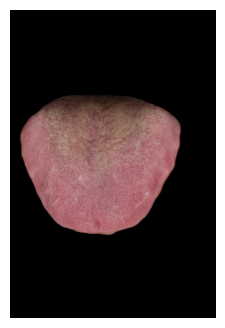

In [60]:
seg_img = nonstain_images[12]

# Display the segmented image
plt.figure(figsize=(4, 4))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

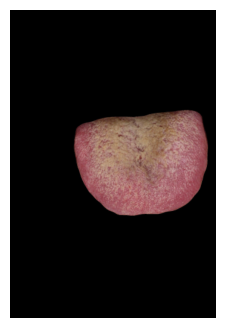

In [61]:
seg_img = nonstain_images[24]

# Display the segmented image
plt.figure(figsize=(4, 4))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

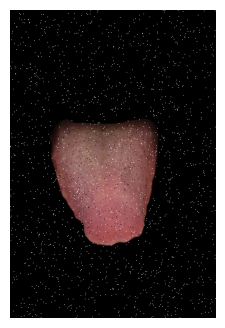

In [62]:
seg_img = nonstain_images[20]

# Display the segmented image
plt.figure(figsize=(4, 4))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

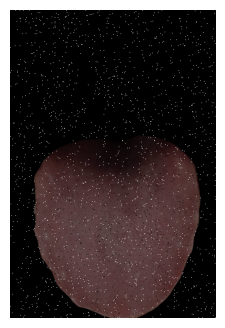

In [63]:
seg_img = nonstain_images[40]

# Display the segmented image
plt.figure(figsize=(4, 4))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# Enhance Functions

In [1]:
import cv2
import numpy as np
import math
from skimage.metrics import structural_similarity as ssim_metric

# ---------- Utility Functions ----------

def filter(max_val, min_val, alpha):
    if min_val > 0:
        ratio = max_val / (min_val + 1e-5)
        return alpha * pow(ratio, alpha) + math.log(ratio)
    return 0.0

def EME(img, kernel=3, alpha=1.0):
    h, w = img.shape
    EME_val = 0.0
    count = 0
    for i in range(0, h, kernel):
        for j in range(0, w, kernel):
            window = img[i:i+kernel, j:j+kernel]
            if window.size == 0:
                continue
            max_val = np.max(window)
            min_val = np.min(window)
            EME_val += filter(max_val, min_val, alpha)
            count += 1
    return EME_val / count if count > 0 else 0.0

def PSNR(img1, img2):
    img1 = np.array(img1, dtype=np.float64)
    img2 = np.array(img2, dtype=np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * math.log10((255.0 ** 2) / mse)

def ssim(img1, img2):
    score, diff = ssim_metric(img1, img2, full=True)
    return score

In [2]:
def median_filter(image, kernel_size):
    return cv2.medianBlur(image, kernel_size)

def gaussian_filter(image, kernel_size=5, sigma=1.0):
    """Adaptive Gaussian smoothing."""
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)


from numpy.lib.stride_tricks import sliding_window_view

def min_filter(img, k):
    pad = k // 2
    padded = np.pad(img, pad, mode="edge")
    windows = sliding_window_view(padded, (k, k))
    return windows.min(axis=(-1, -2)).astype(np.uint8)

def max_filter(img, k):
    pad = k // 2
    padded = np.pad(img, pad, mode="edge")
    windows = sliding_window_view(padded, (k, k))
    return windows.max(axis=(-1, -2)).astype(np.uint8)

In [3]:
# ---------- Enhancement Functions ----------

def clahe_image(img, clip=2.0, tile=8):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    return clahe.apply(img)

def gamma_correction(img, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)


sharpen_weights = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])


def detect_impulse_noise(gray, threshold=0.01):
    """
    Detects if an image has impulse noise.
    threshold: fraction of pixels near 0 or 255 to count as noise
    """
    if gray.dtype != np.uint8:
        gray = np.clip(gray, 0, 255).astype(np.uint8)

    h, w = gray.shape
    num_bright = np.sum(gray >= 255)
    fraction = num_bright / (h * w)
    return fraction > threshold


# Enhance Images

In [155]:
def img_enhancement(img):
    img = img.astype(np.uint8)

    # Convert image to grayscale
    orig_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # ---------------------------------------------------------
    # Stage 0: MIN → MAX filtering
    # ---------------------------------------------------------
    after_min = min_filter(orig_gray, k=3)
    after_max = max_filter(after_min, k=3)

    # ---------------------------------------------------------
    # Stage 1: Median denoising 
    # ---------------------------------------------------------

    best_img_stage1 = after_max
    best_method_stage1 = "min_max"
    best_score_stage1 = 0

    for k in [3, 5, 7]:
        candidate = median_filter(after_max, k)
        score = PSNR(orig_gray, candidate)

        if score > best_score_stage1:
            best_score_stage1 = score
            best_img_stage1 = candidate
            best_method_stage1 = f"min_max_median_{k}"

    # ---------------------------------------------------------
    # HSV Enhancement 
    # ---------------------------------------------------------
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # --- V-channel enhancement using denoised image ---
    v_enhanced = best_img_stage1

    # Merge back to HSV
    hsv_enhanced = cv2.merge([h, s, v_enhanced])

    # Convert to RGB
    final_rgb = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)

    # ---------------------------------------------------------
    # Return results
    # ---------------------------------------------------------
    method_name = best_method_stage1
    final_metric = best_score_stage1

    return final_rgb, method_name, best_score_stage1, final_metric


In [156]:
import os
import cv2
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

def enhance_images(images, image_names=None, save_dir=None, prefix="enhanced_", n_jobs=10):
    results = [None] * len(images)
    method_names = [None] * len(images)
    psnr_scores = [None] * len(images)
    emme_scores = [None] * len(images)

    with ThreadPoolExecutor(max_workers=n_jobs) as executor:
        futures = {executor.submit(img_enhancement, img): i for i, img in enumerate(images)}

        for future in tqdm(as_completed(futures), total=len(images),
                           desc="Enhancing images", dynamic_ncols=True):

            i = futures[future]

            enhanced_img, method_name, psnr, emme = future.result()

            results[i] = enhanced_img
            method_names[i] = method_name
            psnr_scores[i] = psnr
            emme_scores[i] = emme

            # Save enhanced image if requested
            if save_dir is not None and image_names is not None:
                os.makedirs(save_dir, exist_ok=True)
                base_name = os.path.splitext(os.path.basename(image_names[i]))[0]
                save_path = os.path.join(save_dir, f"{prefix}{base_name}_{method_name}.png")

                # Convert RGB → BGR for OpenCV saving
                cv2.imwrite(save_path, cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2BGR))

    return results, method_names, psnr_scores, emme_scores


stain_images_n, stain_methods, stain_psnr, stain_emme = enhance_images(stain_images, stain_names, save_dir="enhanced_stain")

df = pd.DataFrame({
    "image_index": range(len(stain_methods)),
    "image_name": stain_names,
    "best_method": stain_methods,
    "psnr": stain_psnr,
    "emme": stain_emme
})

df.to_csv("enhanced_stain/method_summary.csv", index=False)

Enhancing images: 100%|██████████| 100/100 [00:00<00:00, 226.03it/s]


In [157]:
# Run enhancement on non-stain images
nonstain_images_n, nonstain_methods, nonstain_psnr, nonstain_emme = enhance_images(
    nonstain_images, nonstain_names, save_dir="enhanced_nonstain"
)

# Create DataFrame with all metrics
df_nonstain = pd.DataFrame({
    "image_index": range(len(nonstain_methods)),
    "image_name": nonstain_names,
    "best_method": nonstain_methods,
    "psnr": nonstain_psnr,
    "emme": nonstain_emme
})

# Save CSV
df_nonstain.to_csv("enhanced_nonstain/method_summary.csv", index=False)


Enhancing images: 100%|██████████| 100/100 [00:00<00:00, 299.93it/s]


PermissionError: [Errno 13] Permission denied: 'enhanced_nonstain/method_summary.csv'

# Load saved enhance images

In [6]:
stain_path = r'enhanced_stain'
nonstain_path = r'enhanced_nonstain'

def load_image_unicode(path):
    try:
        with open(path, 'rb') as f:
            data = f.read()
        img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return None

def load_images_from_folder(folder, exts=('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
    images = []
    for filename in sorted(os.listdir(folder)):
        path = os.path.join(folder, filename)
        if os.path.isfile(path) and filename.lower().endswith(exts):
            img = load_image_unicode(path)
            if img is not None:
                images.append(img)
            else:
                print(f"Skipped unreadable: {filename}")
    return images

stain_loaded = load_images_from_folder(stain_path)
nonstain_loaded = load_images_from_folder(nonstain_path)

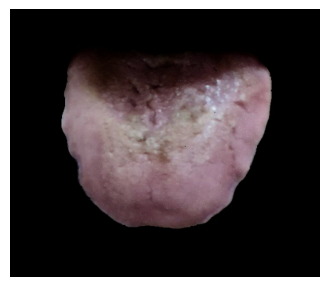

In [7]:
# Display the segmented image
plt.figure(figsize=(4, 4))
plt.imshow(stain_loaded[16], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

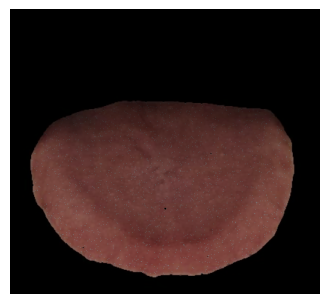

In [8]:
plt.figure(figsize=(4, 4))
plt.imshow(stain_loaded[96], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

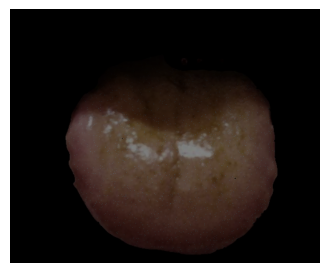

In [9]:
plt.figure(figsize=(4, 4))
plt.imshow(stain_loaded[2], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(stain_images[60], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

orig_gray = cv2.cvtColor(stain_images[60], cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(4, 4))
plt.imshow(orig_gray, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

after_min = min_filter(orig_gray, k=3)
plt.figure(figsize=(4, 4))
plt.imshow(after_min, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

after_max = max_filter(after_min, k=3)
plt.figure(figsize=(4, 4))
plt.imshow(after_max, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()



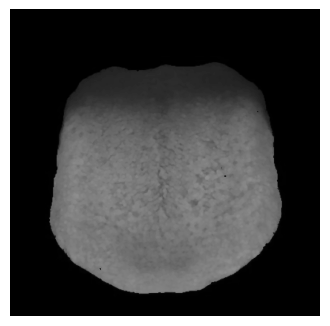

PSNR: 21.00258506396898
Method: min_max_median_3


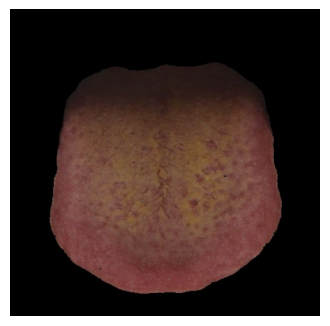

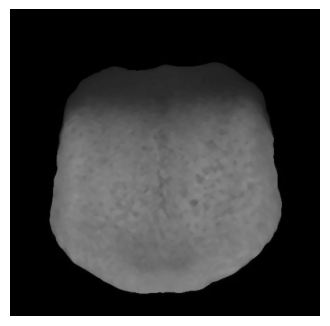

PSNR: 20.9537559714745


In [ ]:
best_img_stage1 = after_max
best_method_stage1 = "min_max"
best_score_stage1 = 0

for k in [3, 5, 7]:
    candidate = median_filter(after_max, k)
    score = PSNR(orig_gray, candidate)

    if score > best_score_stage1:
        best_score_stage1 = score
        best_img_stage1 = candidate
        best_method_stage1 = f"min_max_median_{k}"

plt.figure(figsize=(4, 4))
plt.imshow(best_img_stage1, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

print(f"PSNR: {best_score_stage1}")
print(f"Method: {best_method_stage1}")

plt.figure(figsize=(4, 4))
plt.imshow(stain_loaded[60], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


fake = median_filter(after_max, 7)
plt.figure(figsize=(4, 4))
plt.imshow(fake, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

print(f"PSNR: {PSNR(orig_gray, fake)}")

In [13]:
def remove_black_background(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return (gray > 0).astype(np.uint8) * 255


In [11]:
def enhance_hist(img):
    # -------------------------------------------------
    # 1. Remove background
    # -------------------------------------------------
    bg_mask = remove_black_background(img)

    img_masked = img.copy()
    img_masked[bg_mask == 0] = 0

    # -------------------------------------------------
    # 2. HSV split
    # -------------------------------------------------
    hsv = cv2.cvtColor(img_masked, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    gamma_vals = np.round(np.arange(0.7, 1.5, 0.1), 1)
    clahe_clips = range(1, 8)  # clip = 1 → 7

    # -------------------------------------------------
    # 3. CLAHE grid search on V (EME-driven)
    # -------------------------------------------------
    best_v_clahe = v.copy()
    best_eme_clahe = -np.inf
    best_clip = None

    for clip in clahe_clips:
        clahe = cv2.createCLAHE(
            clipLimit=clip
        )
        v_c = clahe.apply(v)
        score = EME(v_c)

        if score > best_eme_clahe:
            best_eme_clahe = score
            best_v_clahe = v_c
            best_clip = clip

    # -------------------------------------------------
    # 4. Gamma optimization on BEST CLAHE result
    # -------------------------------------------------
    best_v = best_v_clahe.copy()
    best_eme = -np.inf
    best_gamma = None

    for gamma in gamma_vals:
        v_g = gamma_correction(best_v_clahe, gamma)
        score = EME(v_g)

        if score > best_eme:
            best_eme = score
            best_v = v_g
            best_gamma = gamma

    # -------------------------------------------------
    # 5. Reconstruct enhanced image
    # -------------------------------------------------
    hsv_enhanced = cv2.merge([h, s, best_v])
    enhanced_rgb = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)

    enhanced_rgb[bg_mask == 0] = 0

    return enhanced_rgb, {
        "clahe_clip": best_clip,
        "clahe_eme": best_eme_clahe,
        "gamma": best_gamma,
        "gamma_eme": best_eme,
    }


In [14]:
enhanced_stain = []
enhanced_nonstain = []

stain_stats = []
nonstain_stats = []

for img in stain_loaded:
    enhanced_img, stats = enhance_hist(img)
    enhanced_stain.append(enhanced_img)
    stain_stats.append(stats)

for img in nonstain_loaded:
    enhanced_img, stats = enhance_hist(img)
    enhanced_nonstain.append(enhanced_img)
    nonstain_stats.append(stats)

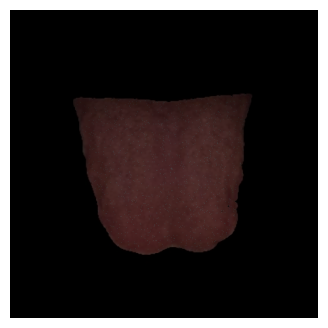

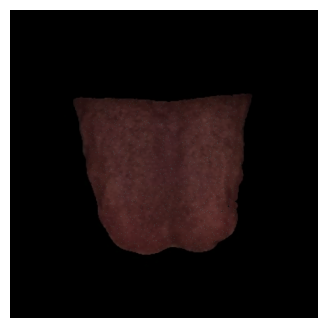

  clahe_clip: 1
  clahe_eme: 1.2792575484658892
  gamma: 0.9
  gamma_eme: 1.3613665739760463


In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(stain_loaded[64], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(enhanced_stain[64], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

for k, v in stain_stats[2].items():
    print(f"  {k}: {v}")

EME 1.2306169290528843
EME 1.210269270031136


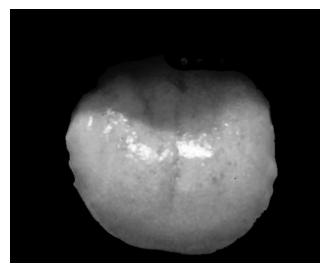

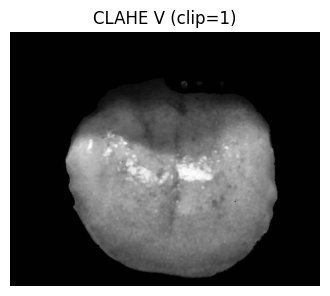

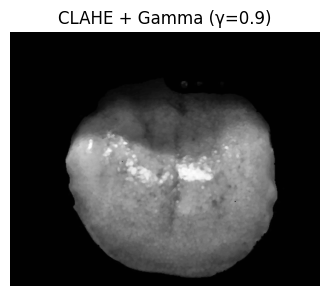

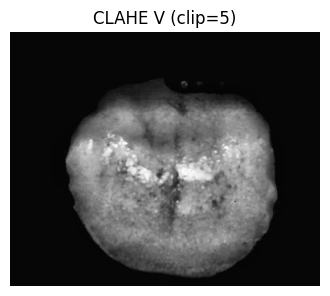

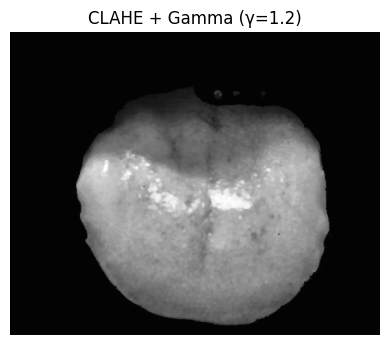

{'best_clahe_clip': 1, 'eme_clahe': 1.2792575484658892, 'best_gamma': 0.9, 'eme_gamma': 1.3613665739760463}


In [ ]:
stats = visualize_v_only(stain_loaded[2])

print(stats)

# Segmentation

In [15]:
import cv2
import numpy as np
from skimage.filters import threshold_sauvola


def remove_black_background(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return (gray > 0).astype(np.uint8) * 255


def make_rgb_stacked_feature(img):
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]
    return np.hstack([r, g, b])

In [16]:
def segment_stains_color_hist(img, method="otsu"):

    # -------------------------------------------------
    # 1. Remove background
    # -------------------------------------------------
    bg_mask = (remove_black_background(img) > 0).astype(np.uint8) * 255

    img_masked = img.copy()
    img_masked[bg_mask == 0] = 0

    # -------------------------------------------------
    # 2. Convert to LAB
    # -------------------------------------------------
    lab = cv2.cvtColor(img_masked, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)

    # -------------------------------------------------
    # 3. Normalize channels
    # -------------------------------------------------
    Lf = L.astype(np.float32) / 255.0
    Af = (A.astype(np.float32) - 128) / 128.0
    Bf = (B.astype(np.float32) - 128) / 128.0

    # -------------------------------------------------
    # 4. Tongue baseline
    # -------------------------------------------------
    tongue_pixels = bg_mask > 0

    L_med = np.median(Lf[tongue_pixels])
    A_med = np.median(Af[tongue_pixels])
    B_med = np.median(Bf[tongue_pixels])

    # -------------------------------------------------
    # 5. Stain score
    # -------------------------------------------------
    dL = np.abs(Lf - L_med)
    dC = np.sqrt((Af - A_med)**2 + (Bf - B_med)**2)

    stain_score = 0.6 * dL + 0.4 * dC
    stain_score[~tongue_pixels] = 0

    # Normalize to 8-bit
    stain_score = cv2.normalize(
        stain_score, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    # -------------------------------------------------
    # 6. Threshold
    # -------------------------------------------------
    if method.lower() == "otsu":
        _, stain_mask = cv2.threshold(
            stain_score, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

    elif method.lower() == "sauvola":
        score_norm = stain_score.astype(np.float32) / 255.0
        t = threshold_sauvola(score_norm, window_size=49, k=0.2)
        stain_mask = (score_norm > t).astype(np.uint8) * 255

    else:
        raise ValueError("method must be 'otsu' or 'sauvola'")
    
    # -------------------------------------------------
    # 6.5 Morphological cleanup (morphologyEx ONLY)
    # -------------------------------------------------

    kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    kernel_med   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # 1. Remove isolated noise (light opening)
    stain_mask = cv2.morphologyEx(
        stain_mask, cv2.MORPH_OPEN, kernel_small
    )

    # 2. Fill small gaps / holes inside stains
    stain_mask = cv2.morphologyEx(
        stain_mask, cv2.MORPH_CLOSE, kernel_med
    )


    # -------------------------------------------------
    # 7. Enforce foreground
    # -------------------------------------------------
    final_mask = cv2.bitwise_and(stain_mask, bg_mask)

    segmented_img = img.copy()
    segmented_img[final_mask == 0] = 0

    return segmented_img, final_mask


In [17]:
def img_segmentation(img, method='otsu'):
    segmented_img, mask= segment_stains_color_hist(img, method)
    return segmented_img, mask

In [18]:
stain_segments_otsu = []
mask_segments_otsu = []

# Segment images
for img in enhanced_stain:
    result, stains = img_segmentation(img, method="otsu")
    stain_segments_otsu.append(result)
    mask_segments_otsu.append(stains)


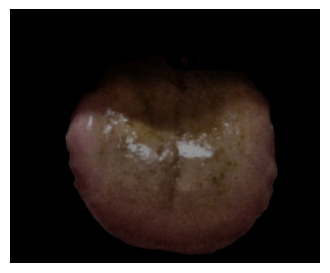

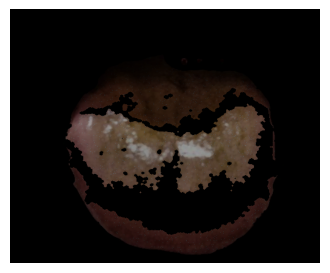

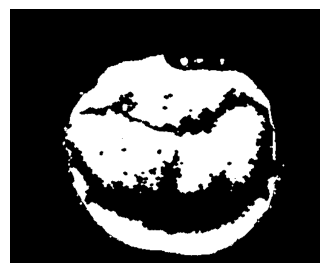

In [19]:
plt.figure(figsize=(4, 4))
plt.imshow(enhanced_stain[2], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(stain_segments_otsu[2], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(mask_segments_otsu[2], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [20]:
nonstain_segments_otsu = []
nonmask_segments_otsu = []

# Segment images
for img in enhanced_nonstain:
    result, stains = img_segmentation(img, method="otsu")
    nonstain_segments_otsu.append(result)
    nonmask_segments_otsu.append(stains)


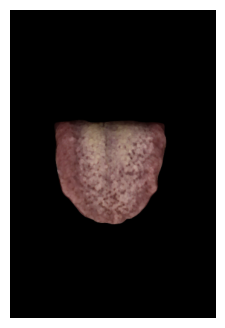

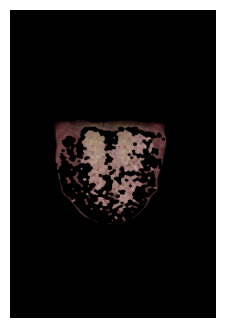

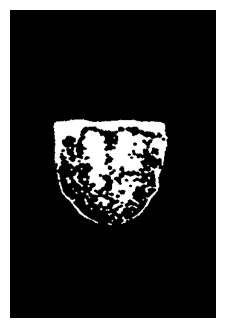

In [21]:
plt.figure(figsize=(4, 4))
plt.imshow(enhanced_nonstain[15], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(nonstain_segments_otsu[15], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(nonmask_segments_otsu[15], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [22]:
stain_segments_sauvola = []
mask_segments_sauvola = []

# Segment images
for img in enhanced_stain:
    result, stains = img_segmentation(img, method="sauvola")
    stain_segments_sauvola.append(result)
    mask_segments_sauvola.append(stains)


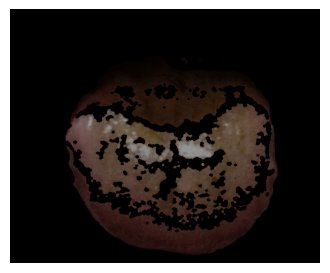

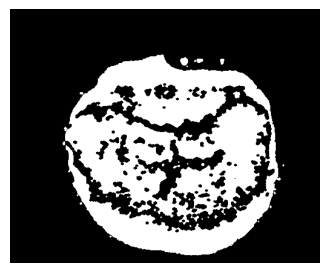

In [23]:
plt.figure(figsize=(4, 4))
plt.imshow(stain_segments_sauvola[2], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(mask_segments_sauvola[2], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [24]:
nonstain_segments_sauvola = []
nonmask_segments_sauvola = []

# Segment images
for img in enhanced_nonstain:
    result, stains = img_segmentation(img, method="sauvola")
    nonstain_segments_sauvola.append(result)
    nonmask_segments_sauvola.append(stains)

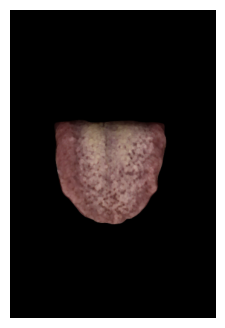

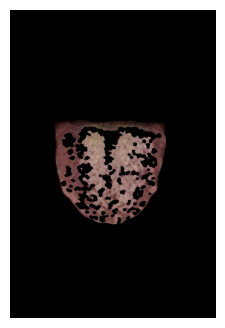

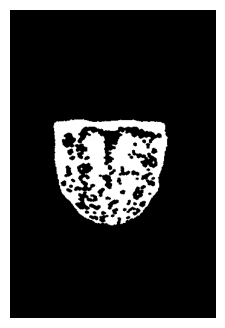

In [25]:
plt.figure(figsize=(4, 4))
plt.imshow(enhanced_nonstain[15], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(nonstain_segments_sauvola[15], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(nonmask_segments_sauvola[15], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# Extracting Features

In [235]:
def projection_features(binary_img, threshold=0, target_len=512):

    # -------------------------------------------------
    # 1. Greyscale
    # -------------------------------------------------
    if binary_img.ndim == 3:
        gray = cv2.cvtColor(binary_img, cv2.COLOR_RGB2GRAY)
    else:
        gray = binary_img.copy()

    gray = gray.astype(np.uint8)

    # -------------------------------------------------
    # 2. Binary (0 / 1)
    # -------------------------------------------------
    bin_img = (gray > threshold).astype(np.uint8)

    # -------------------------------------------------
    # 3. Raw projections (INTEGER COUNTS)
    # -------------------------------------------------
    h_proj = np.sum(bin_img, axis=1).astype(np.int32)
    v_proj = np.sum(bin_img, axis=0).astype(np.int32)

    # -------------------------------------------------
    # 4. Resize 
    # -------------------------------------------------
    if target_len is not None:
        xh_old = np.linspace(0, 1, len(h_proj))
        xv_old = np.linspace(0, 1, len(v_proj))
        x_new  = np.linspace(0, 1, target_len)

        h_proj = np.interp(x_new, xh_old, h_proj)
        v_proj = np.interp(x_new, xv_old, v_proj)

    return h_proj, v_proj


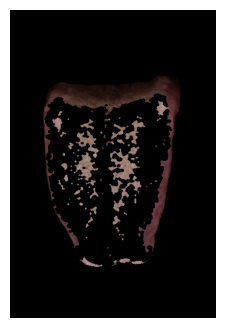

array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   5.,  25.,
        28.,  36.,  38.,  41.,  43.,  45.,  46.,  48.,  60.,  68.,  93.,
        97., 140., 171., 210., 212., 214., 213., 216., 217., 218., 219.,
       220., 221., 222., 223., 224., 223., 221., 216., 213., 209., 206.,
       204., 200., 191., 185., 179., 170., 168., 16

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.  

In [236]:
plt.figure(figsize=(4, 4))
plt.imshow(nonstain_segments_otsu[12], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

h_stain, v_stain = projection_features(nonstain_segments_otsu[12])

display(h_stain)
display(v_stain)


In [265]:
def show_binary(img, threshold=0):
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img.copy()

    bin_img = (gray > threshold).astype(np.uint8)

    plt.figure(figsize=(4, 4))
    plt.imshow(bin_img, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.show()

    print("Unique values:", np.unique(bin_img))


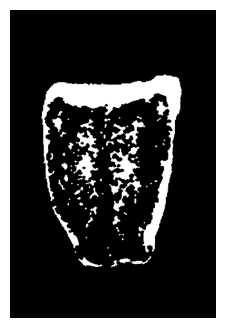

Unique values: [0 1]


In [266]:
show_binary(nonstain_segments_otsu[12])


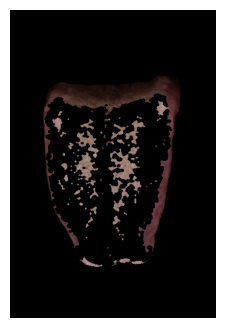

array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   5.,  25.,
        28.,  36.,  38.,  41.,  43.,  45.,  46.,  48.,  60.,  68.,  93.,
        97., 140., 171., 210., 212., 214., 213., 216., 217., 218., 219.,
       220., 221., 222., 223., 224., 223., 221., 216., 213., 209., 206.,
       204., 200., 191., 185., 179., 170., 168., 16

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.  

In [239]:
plt.figure(figsize=(4, 4))
plt.imshow(nonstain_segments_otsu[12], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

h_stain, v_stain = projection_features(nonstain_segments_otsu[12])

display(h_stain)
display(v_stain)

In [240]:
import mahotas as mt

def extract_features(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    textures = mt.features.haralick(gray)
    ht_mean = textures.mean(axis=0)

    return ht_mean   # shape: (13,)

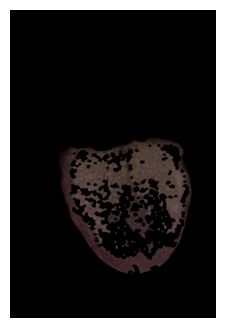

,Value
0,0.730
1,69.229
2,0.915
3,408.956
4,0.898
5,15.119
6,1566.596
7,1.620
8,2.058
9,0.008


In [241]:
plt.figure(figsize=(4, 4))
plt.imshow(nonstain_segments_otsu[42], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

haralick = extract_features(nonstain_segments_otsu[42])


df = pd.DataFrame(
    np.round(haralick, 3),
    columns=["Value"]
)

display(df)

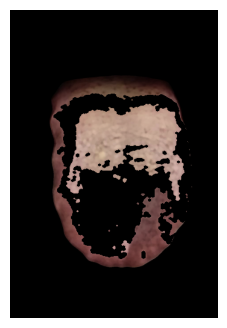

array([ 6.23877876e-01,  2.24707151e+02,  9.57379276e-01,  2.63568433e+03,
        8.61863576e-01,  4.52354683e+01,  1.03180302e+04,  2.39400406e+00,
        3.00637802e+00,  3.46711798e-03,  1.30058595e+00, -5.76048726e-01,
        9.54748559e-01])

In [242]:
plt.figure(figsize=(4, 4))
plt.imshow(stain_segments_otsu[31], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

haralick = extract_features(stain_segments_otsu[31])

display(haralick)

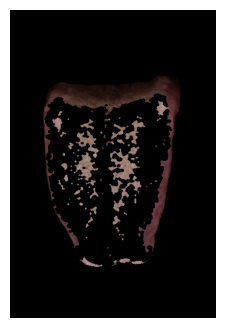

array([ 7.72907523e-01,  2.49484431e+02,  8.31706378e-01,  7.41102829e+02,
        9.10821814e-01,  1.57324125e+01,  2.71492688e+03,  1.45889932e+00,
        1.84829226e+00,  4.81466422e-03,  9.73072360e-01, -5.16843226e-01,
        8.50432859e-01])

array([ 7.72907523e-01,  2.49484431e+02,  8.31706378e-01,  7.41102829e+02,
        9.10821814e-01,  1.57324125e+01,  2.71492688e+03,  1.45889932e+00,
        1.84829226e+00,  4.81466422e-03,  9.73072360e-01, -5.16843226e-01,
        8.50432859e-01])

In [243]:
plt.figure(figsize=(4, 4))
plt.imshow(nonstain_segments_otsu[12], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

haralick = extract_features(nonstain_segments_otsu[12])

display(haralick)
display(haralick)

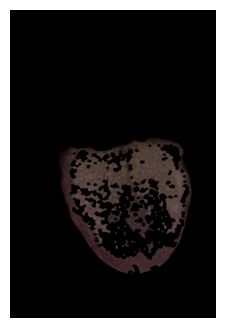

array([ 7.30252163e-01,  6.92292876e+01,  9.15372138e-01,  4.08956296e+02,
        8.97521002e-01,  1.51185322e+01,  1.56659590e+03,  1.62008408e+00,
        2.05815781e+00,  7.58077915e-03,  1.06413323e+00, -4.93995609e-01,
        8.60208823e-01])

In [244]:
plt.figure(figsize=(4, 4))
plt.imshow(nonstain_segments_otsu[42], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

haralick = extract_features(nonstain_segments_otsu[42])

display(haralick)

In [245]:
def lbp_feature_rgb(img_rgb, kernel_size=3, normalize=False, concatenate=True):

    assert img_rgb.ndim == 3 and img_rgb.shape[2] == 3, "Input must be RGB"

    h, w, _ = img_rgb.shape
    pad = kernel_size // 2

    num_neighbors = kernel_size * kernel_size - 1
    num_bins = 2 ** num_neighbors

    center_idx = (kernel_size * kernel_size) // 2

    channel_hists = []

    for c in range(3):  # R, G, B
        img = img_rgb[:, :, c]
        padded_img = np.pad(img, pad, mode='edge')

        hist = np.zeros(num_bins, dtype=float)

        for i in range(h):
            for j in range(w):
                window = padded_img[i:i+kernel_size, j:j+kernel_size].flatten()
                center_pixel = window[center_idx]

                binary = (window >= center_pixel).astype(int)
                binary = np.delete(binary, center_idx)

                lbp_value = 0
                for k in range(len(binary)):
                    lbp_value += binary[k] * (2 ** k)

                hist[int(lbp_value)] += 1

        if normalize:
            hist /= hist.sum()

        channel_hists.append(hist)

    if concatenate:
        return np.concatenate(channel_hists)  # shape: (3 * num_bins,)
    else:
        return tuple(channel_hists)  # (hist_R, hist_G, hist_B)

In [246]:
import numpy as np

def lbp_image_single_channel(img, kernel_size=3):
    h, w = img.shape
    pad = kernel_size // 2
    padded = np.pad(img, pad, mode='edge')

    center_idx = (kernel_size * kernel_size) // 2
    lbp_img = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            window = padded[i:i+kernel_size, j:j+kernel_size].flatten()
            center = window[center_idx]

            binary = (window >= center).astype(int)
            binary = np.delete(binary, center_idx)

            value = 0
            for k in range(len(binary)):
                value += binary[k] * (2 ** k)

            lbp_img[i, j] = value

    return lbp_img


def visualize_lbp(img_rgb, kernel_size=3):
    channels = ['R', 'G', 'B']

    for c in range(3):

        # ---------------------------
        # Original channel
        # ---------------------------
        plt.figure(figsize=(4, 4))
        plt.imshow(img_rgb[:, :, c], cmap='gray')
        plt.title(f'{channels[c]}')
        plt.axis('off')
        plt.show()

        # ---------------------------
        # LBP image
        # ---------------------------
        lbp_img = lbp_image_single_channel(img_rgb[:, :, c], kernel_size)

        plt.figure(figsize=(4, 4))
        plt.imshow(lbp_img, cmap='gray')
        plt.title(f'LBP {channels[c]}')
        plt.axis('off')
        plt.show()

        # ---------------------------
        # LBP histogram (RAW counts)
        # ---------------------------
        plt.figure(figsize=(6, 4))
        plt.hist(lbp_img.ravel(), bins=256)
        plt.title(f'LBP Histogram {channels[c]}')
        plt.xlabel("LBP value")
        plt.ylabel("Count")
        plt.show()

    
def plot_lbp_histogram(img_rgb, kernel_size=3):
    lbp_hist = lbp_feature_rgb(img_rgb, kernel_size=kernel_size)

    plt.figure(figsize=(10, 4))
    plt.plot(lbp_hist)
    plt.title("Concatenated RGB LBP Histogram")
    plt.ylabel("Frequency")
    plt.show()


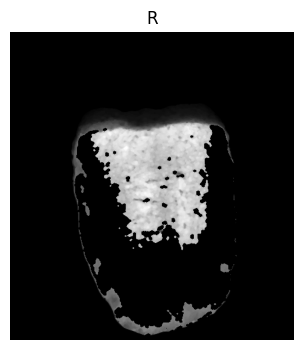

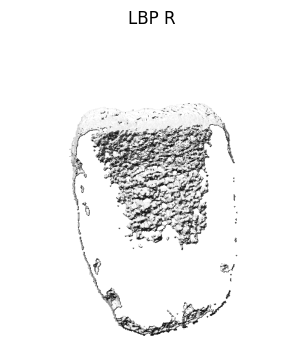

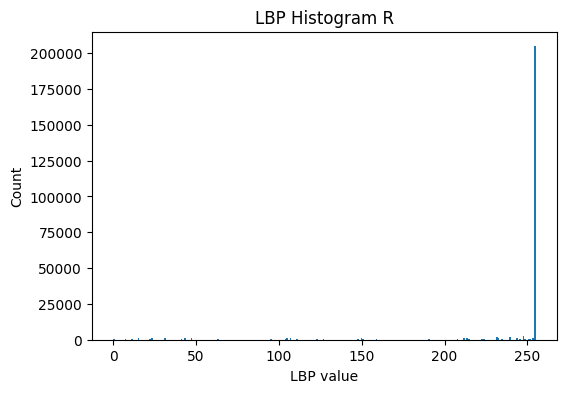

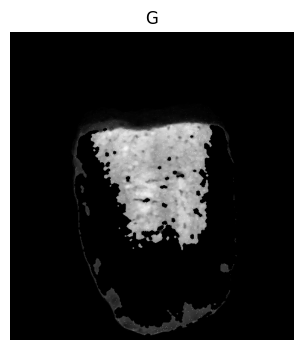

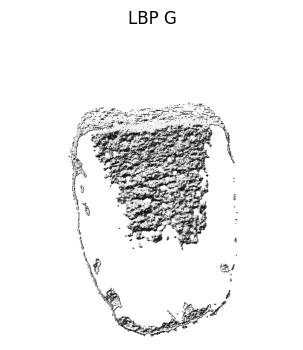

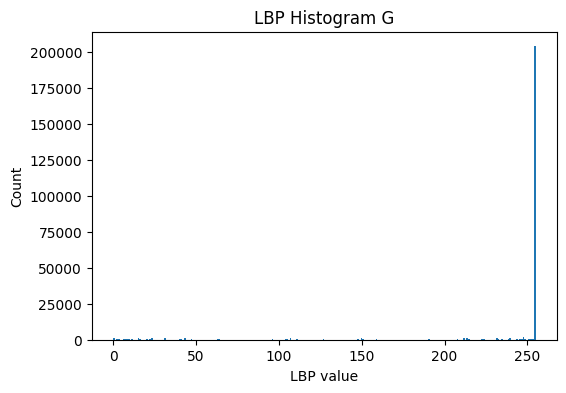

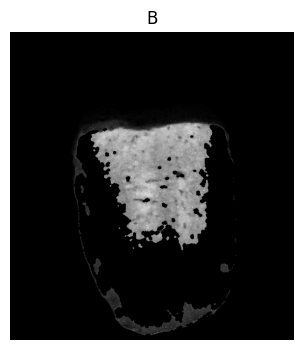

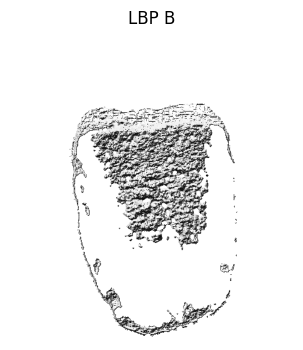

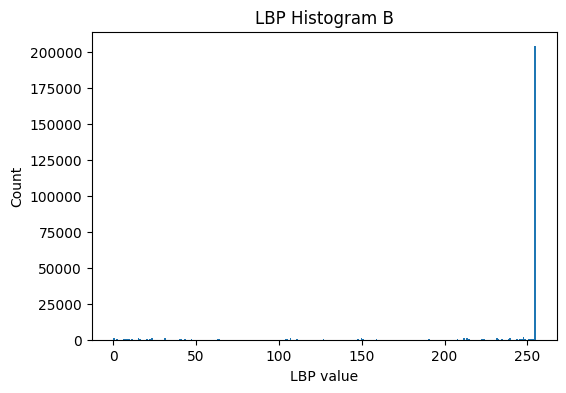

In [247]:
visualize_lbp(stain_segments_otsu[8], kernel_size=3)


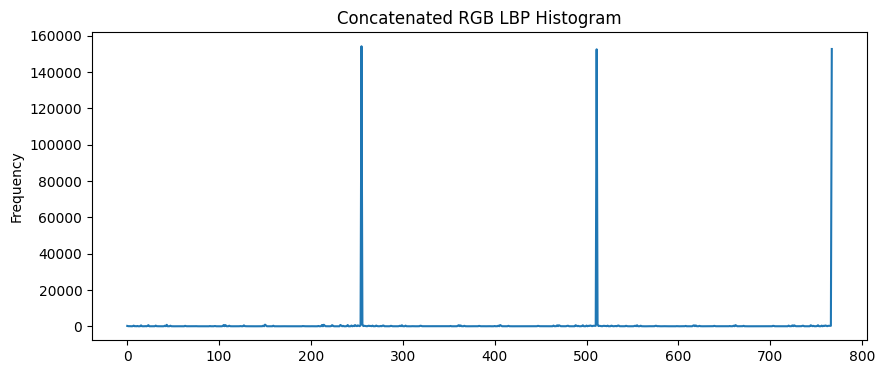

In [248]:
plot_lbp_histogram(nonstain_segments_otsu[42], kernel_size=3)


In [26]:
from scipy.stats import skew, kurtosis

def extract_rgb_histo(img, eps=1e-8):

    hist_features = []
    stats_features = []

    for c in range(3):  # R, G, B
        channel = img[:, :, c].astype(np.float32)

        # -----------------------------
        # Histogram
        # -----------------------------
        h, _ = np.histogram(channel, bins=256, range=(0, 256))
        h = h.astype(np.float32)
        hist_features.append(h)

        # Normalize histogram for entropy
        p = h / (h.sum() + eps)

        # -----------------------------
        # Statistics
        # -----------------------------
        mean = np.mean(channel)
        std = np.std(channel)

        smoothness = 1.0 - (1.0 / (1.0 + std**2))
        sk = skew(channel.reshape(-1))
        kurt = kurtosis(channel.reshape(-1), fisher=False)  # Pearson kurtosis
        entropy = -np.sum(p * np.log2(p + eps))

        stats_features.extend([
            mean,
            std,
            smoothness,
            sk,
            kurt,
            entropy
        ])

    # Concatenate everything
    hist = np.concatenate(hist_features)
    stats = np.array(stats_features, dtype=np.float32)

    feature_vector = np.concatenate([hist, stats])

    return feature_vector


In [27]:
def compute_rgb_hist_and_stats(img, eps=1e-8):

    channel_hists = []
    channel_stats = []
    channel_names = ['R', 'G', 'B']

    for c in range(3):
        channel = img[:, :, c].astype(np.float32)

        # Histogram
        h, _ = np.histogram(channel, bins=256, range=(0, 256))
        h = h.astype(np.float32)
        channel_hists.append(h)

        # Probability for entropy
        p = h / (h.sum() + eps)

        # Statistics
        mean = np.mean(channel)
        std = np.std(channel)
        smoothness = 1.0 - (1.0 / (1.0 + std**2))
        sk = skew(channel.reshape(-1))
        kurt = kurtosis(channel.reshape(-1), fisher=False)
        entropy = -np.sum(p * np.log2(p + eps))

        channel_stats.append([mean, std, smoothness, sk, kurt, entropy])

    concat_hist = np.concatenate(channel_hists)
    channel_stats = np.array(channel_stats)

    return channel_hists, concat_hist, channel_stats, channel_names

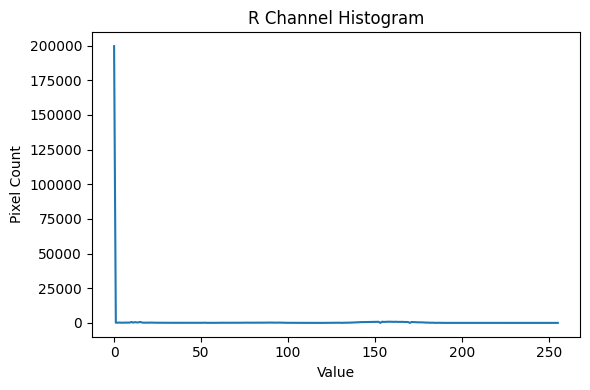

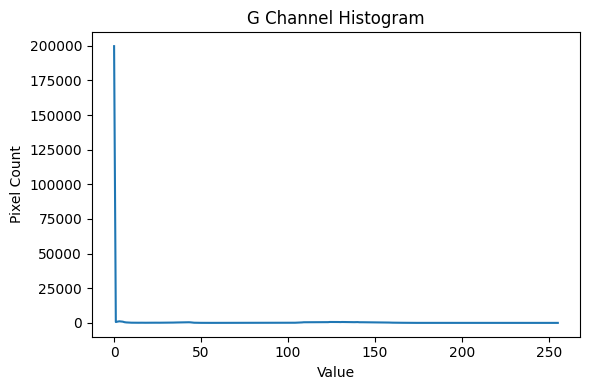

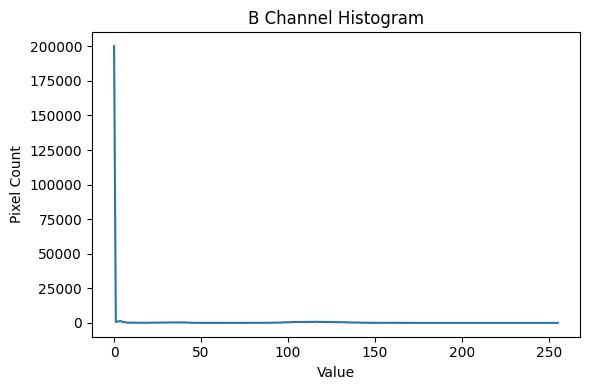

In [30]:
channel_hists, concat_hist, channel_stats, channel_names = compute_rgb_hist_and_stats(stain_segments_otsu[8])

for i in range(3):
    plt.figure(figsize=(6, 4))
    plt.plot(channel_hists[i])
    plt.title(f"{channel_names[i]} Channel Histogram")
    plt.xlabel("Value")
    plt.ylabel("Pixel Count")
    plt.tight_layout()
    plt.show()

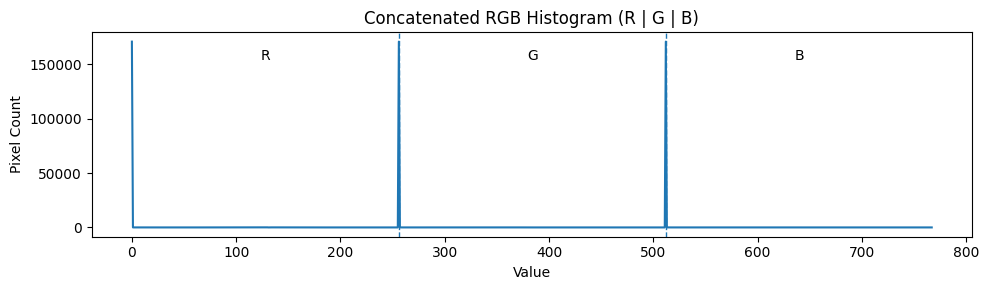

In [29]:
plt.figure(figsize=(10, 3))
plt.plot(concat_hist)
plt.axvline(256, linestyle='--', linewidth=1)
plt.axvline(512, linestyle='--', linewidth=1)

plt.text(128, max(concat_hist)*0.9, 'R', ha='center')
plt.text(384, max(concat_hist)*0.9, 'G', ha='center')
plt.text(640, max(concat_hist)*0.9, 'B', ha='center')

plt.title("Concatenated RGB Histogram (R | G | B)")
plt.xlabel("Value")
plt.ylabel("Pixel Count")
plt.tight_layout()
plt.show()


In [32]:
import numpy as np
from scipy.stats import skew, kurtosis

def print_rgb_statistics(img, eps=1e-8):

    channel_names = ['R', 'G', 'B']
    stat_names = ['Mean', 'Std', 'Smoothness', 'Skew', 'Kurtosis', 'Entropy']

    for c in range(3):
        channel = img[:, :, c].astype(np.float32)

        # Histogram (for entropy)
        h, _ = np.histogram(channel, bins=256, range=(0, 256))
        p = h / (h.sum() + eps)

        # Statistics
        mean = np.mean(channel)
        std = np.std(channel)
        smoothness = 1.0 - (1.0 / (1.0 + std**2))
        sk = skew(channel.reshape(-1))
        kurt = kurtosis(channel.reshape(-1), fisher=False)
        entropy = -np.sum(p * np.log2(p + eps))

        stats = [mean, std, smoothness, sk, kurt, entropy]

        print(f"\n{channel_names[c]} channel statistics")
        print("-" * 30)
        for name, val in zip(stat_names, stats):
            print(f"{name:<12}: {val:.3f}")


In [33]:
print_rgb_statistics(stain_segments_otsu[8])



R channel statistics
------------------------------
Mean        : 20.495
Std         : 50.855
Smoothness  : 1.000
Skew        : 2.250
Kurtosis    : 6.298
Entropy     : 1.825

G channel statistics
------------------------------
Mean        : 16.131
Std         : 42.066
Smoothness  : 0.999
Skew        : 2.420
Kurtosis    : 7.139
Entropy     : 1.802

B channel statistics
------------------------------
Mean        : 14.397
Std         : 37.600
Smoothness  : 0.999
Skew        : 2.426
Kurtosis    : 7.186
Entropy     : 1.767


In [250]:
def box_counting_features(
    img,
    box_sizes=[2, 4, 8, 12, 22, 40, 75, 128],
    bin_thresh=5,
    variation_thresh=0
):
    # -------------------------------------------------
    # Grayscale
    # -------------------------------------------------
    if img.ndim == 3:  # RGB
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img.copy()

    img_gray = img_gray.astype(np.uint8)

    # -------------------------------------------------
    # Binary
    # -------------------------------------------------
    binary = (img_gray > bin_thresh).astype(np.uint8) * 255

    h, w = binary.shape
    box_counts = []

    # -------------------------------------------------
    # Box counting
    # -------------------------------------------------
    for bs in box_sizes:
        count = 0

        for i in range(0, h - bs + 1, bs):
            for j in range(0, w - bs + 1, bs):
                patch = binary[i:i+bs, j:j+bs]

                # Non-homogeneous box
                if patch.max() - patch.min() > variation_thresh:
                    count += 1

        box_counts.append(count)

    box_counts = np.array(box_counts, dtype=np.float32)
    box_sizes = np.array(box_sizes, dtype=np.float32)

    # -------------------------------------------------
    # Fractal slope
    # -------------------------------------------------
    valid = box_counts > 0

    if valid.sum() >= 2:
        log_sizes  = np.log(1.0 / box_sizes[valid])
        log_counts = np.log(box_counts[valid])
        slope, _ = np.polyfit(log_sizes, log_counts, 1)
    else:
        slope = 0.0

    # -------------------------------------------------
    # Feature vector
    # -------------------------------------------------
    feature_vector = np.concatenate([box_counts, [slope]])

    return feature_vector


In [251]:
def concat_vector(img, proj_len=512):

    h_proj, v_proj = projection_features(
        img,
        target_len=proj_len
    )

    assert h_proj.size == proj_len
    assert v_proj.size == proj_len

    haralick = extract_features(img)
    assert haralick.size == 13

    lbp = lbp_feature_rgb(img, kernel_size=3)
    assert lbp.size == 256 * 3

    rgb_hist = extract_rgb_histo(img)
    assert rgb_hist.size == 786

    box_count = box_counting_features(img)
    assert box_count.size == 9

    feature_vector = np.concatenate([
        h_proj,
        v_proj,
        haralick,
        lbp,
        rgb_hist,
        box_count
    ]).astype(np.float32)

    expected_len = 2 * proj_len + 13 + 768 + 786 + 9

    if feature_vector.ndim != 1:
        raise ValueError("Feature vector is not 1D")

    if feature_vector.size != expected_len:
        raise ValueError(
            f"Feature length mismatch: {feature_vector.size} != {expected_len}"
        )

    return np.nan_to_num(feature_vector)


In [252]:
#Empty

In [253]:
stain_otsu_vector = []
nonstain_otsu_vector = []

for img in stain_segments_otsu:
    feature = concat_vector(img)
    stain_otsu_vector.append(feature)

for img in nonstain_segments_otsu:
    feature = concat_vector(img)
    nonstain_otsu_vector.append(feature)

In [254]:
stain_sauvola_vector = []
nonstain_sauvola_vector = []

for img in stain_segments_otsu:
    feature = concat_vector(img)
    stain_sauvola_vector.append(feature)

for img in nonstain_segments_otsu:
    feature = concat_vector(img)
    nonstain_sauvola_vector.append(feature)

In [255]:
lengths = [len(v) for v in stain_otsu_vector + nonstain_otsu_vector]
print(sorted(set(lengths)))


[2600]


# Training SVM

In [256]:
from sklearn.model_selection import train_test_split

X = stain_otsu_vector + nonstain_otsu_vector
y = [1] * len(stain_otsu_vector) + [0] * len(nonstain_otsu_vector)  # 1=stain, 0=nonstain

segments = stain_otsu_vector + nonstain_otsu_vector

# Split 85% train / 15% test
X_train, X_test, y_train, y_test, seg_train, seg_test = train_test_split(
    X, y, segments, test_size=0.15, random_state=1, stratify=y)

In [257]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [258]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

svm_classifier = SVC(kernel='rbf', C=1.0)
svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[15  0]
 [ 6  9]]


In [259]:
def cal_accuracy(pred,actual):
    correct = np.sum(np.array(pred) == np.array(actual))
    accuracy = correct/len(actual)*100
    print(accuracy)

print(f"Accuracy:")
cal_accuracy(y_pred,y_test)

Accuracy:
80.0


In [260]:
X = np.vstack(stain_sauvola_vector + nonstain_sauvola_vector)

y = [1] * len(stain_sauvola_vector) + [0] * len(nonstain_sauvola_vector)  # 1=stain, 0=nonstain

segments = stain_sauvola_vector + nonstain_sauvola_vector

# Split 85% train / 15% test
X_train, X_test, y_train, y_test, seg_train, seg_test = train_test_split(
    X, y, segments, test_size=0.15, random_state=1, stratify=y)

In [261]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [262]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

svm_classifier = SVC(kernel='rbf', C=1.0)
svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[15  0]
 [ 6  9]]


In [263]:
def cal_accuracy(pred,actual):
    correct = np.sum(np.array(pred) == np.array(actual))
    accuracy = correct/len(actual)*100
    print(accuracy)

print(f"Accuracy:")
cal_accuracy(y_pred,y_test)

Accuracy:
80.0


# Show Off for slides